<a href="https://colab.research.google.com/github/Sanskar-cpu-sudo/Deep-Learning/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This program uses TensorFlow and Keras to build, train, evaluate, and test a neural network for recognizing handwritten digits from the MNIST dataset.

import tensorflow as tf
import matplotlib.pyplot as plt

ImportError: initialization failed

In [ ]:
# Get data and split into train and test datasets
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Scale down values of pixels from 0-255 to 0-1
train_images = train_images /255.0
test_images = test_images / 255.0

(60000, 28, 28)
(10000, 28, 28)
[5 0 4 ... 5 6 8]


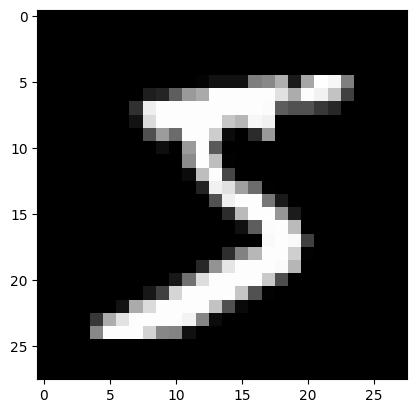

In [ ]:
# Visualizing data
print(train_images.shape)
print(test_images.shape)
print(train_labels)

# Display first image
plt.imshow(train_images[0], cmap='gray')
plt.show()

In [ ]:
# Defining neural network model
my_model = tf.keras.models.Sequential()
my_model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
my_model.add(tf.keras.layers.Dense(128, activation='relu'))     #Rectified Linear Unit        #Dense layers are used to learn complex patterns in data.
my_model.add(tf.keras.layers.Dense(10, activation='softmax'))   #softmax is often used as the activation function in the output layer for classification tasks

# Compiling the model
my_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) #Adaptive Moment Estimation #sparse_categorical_crossentropy for multi-class classification

# Training the model
my_model.fit(train_images, train_labels, epochs=3)

d:\Documents\ML\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9269 - loss: 0.2556
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9649 - loss: 0.1148
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9769 - loss: 0.0772


In [ ]:
# Checking model accuracy on test data
val_loss, val_acc = my_model.evaluate(test_images, test_labels)
print('Test accuracy: ', val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9694 - loss: 0.0994
Test accuracy:  0.9693999886512756


In [ ]:
my_model.save('my_mnist_model.keras')

In [ ]:
my_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

In [ ]:
# Predict on test images
predictions = my_model.predict(test_images)
predicted_labels = tf.argmax(predictions, axis=1)

print("First 10 Predictions:", predicted_labels[:10].numpy())
print("First 10 Actual     :", test_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
First 10 Predictions: [7 2 1 0 4 1 4 9 5 9]
First 10 Actual     : [7 2 1 0 4 1 4 9 5 9]


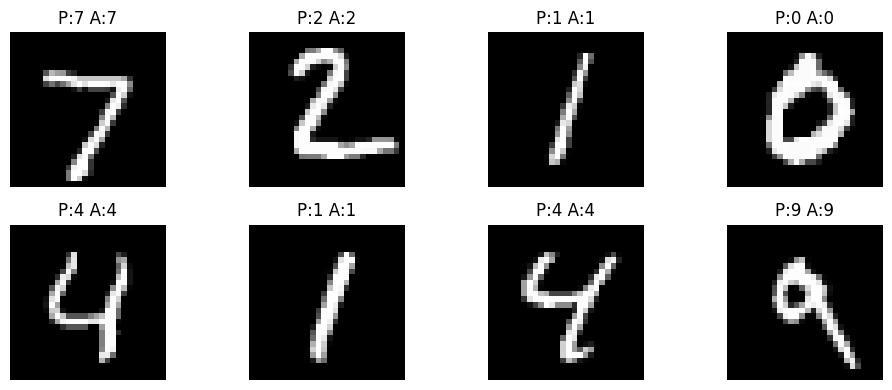

In [ ]:
# Display a few predictions
plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(test_images[i], cmap='gray')
    plt.title(f'P:{predicted_labels[i].numpy()} A:{test_labels[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix
cm = tf.math.confusion_matrix(test_labels, predicted_labels)
print(cm.numpy())

[[ 961    0    1    2    1    2    2   10    1    0]
 [   0 1128    2    0    0    1    1    0    3    0]
 [   4   13  977   12    7    0    2   13    4    0]
 [   0    0    0  997    0    4    0    5    2    2]
 [   1    0    2    0  966    0    2    3    1    7]
 [   2    0    0   16    1  865    2    2    2    2]
 [   5    3    3    1   11   10  917    1    6    1]
 [   0    8    4    4    1    1    0 1003    1    6]
 [   3    3    2   13    9   12    1    9  913    9]
 [   2    4    0    9   12    9    0    5    1  967]]
